In [1]:
import faiss
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from ast import literal_eval
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from scipy.stats import zscore, entropy
import json

In [2]:
# --- Load metadata first ---
with open('data/meta-kst.json', 'r') as f:
    meta_kst = json.load(f)

with open('data/meta-reports.json', 'r') as f:
    meta_reports = json.load(f)

In [3]:
# --- Identify relevant IDs early ---
kst_proc_ids = {
    m['id_'] for m in meta_kst
    if 'verslag' in m['sub_source'].lower()
}

report_ids = {
    m['_id'] for m in meta_reports
    if not any(e in m['_id'].lower() for e in {"verantw", "jaarverslag", ":vo-", "trendrapport"})
}

# --- Load metadata-filtered dataframe ---
usecols = ['published_at', 'sid', 'sentences', '_id']
df = pd.read_csv('data/subset/sentences.tsv', sep='\t', usecols=usecols)

# Keep only rows relevant to filtered metadata
mask = (
    df.sid.str.split('_s').str[0].isin(kst_proc_ids)
    | df['_id'].isin(report_ids)
)
df = df[mask].reset_index(drop=False)  # keep original FAISS indices

# --- Load FAISS index ---
index = faiss.read_index('data/subset/sentences.faiss')

# --- Reconstruct only needed embeddings ---
# Note: df['index'] is the original row index (FAISS vector position)
xb = np.vstack([index.reconstruct(int(i)) for i in df['index']]).astype('float32')
xb = normalize(xb, axis=1)

In [4]:
# Ensure both sets are normalized (unit vectors)
report_vecs = xb[df['_id'].isin(report_ids)]
kst_vecs = xb[df.sid.str.split('_s').str[0].isin(kst_proc_ids)]

report_df = df[df['_id'].isin(report_ids)].reset_index(drop=True)
kst_df = df[df.sid.str.split('_s').str[0].isin(kst_proc_ids)].reset_index(drop=True)

# --- Build FAISS index for KST embeddings ---
d = kst_vecs.shape[1]
index = faiss.IndexFlatIP(d)  # inner product = cosine similarity if normalized
index.add(kst_vecs)

# --- Search ---
k = 25  # number of nearest neighbors to check per query (tune this)
D, I = index.search(report_vecs, k)  # D = similarity, I = indices into kst_df

# --- Filter by similarity threshold ---
threshold = 0.85
rows = []
for i, (scores, idxs) in enumerate(zip(D, I)):
    mask = scores > threshold
    if not np.any(mask):
        continue
    for score, j in zip(scores[mask], idxs[mask]):
        rows.append({
            "report_sent": report_df.loc[i, "sentences"],
            "report_date": report_df.loc[i, "published_at"],
            "kst_sent": kst_df.loc[j, "sentences"],
            "kst_date": kst_df.loc[j, "published_at"],
            "similarity": float(score)
        })

In [19]:
results = pd.DataFrame(rows)
results = results.drop_duplicates(subset=['kst_sent','report_sent'])
# results = results[
#     ~results['kst_sent'].str.contains(r'\d', regex=True) &
#     ~results['report_sent'].str.contains(r'\d', regex=True)
# ]

In [21]:
results['kst_date'] = pd.to_datetime(results.kst_date)
results['report_date'] = pd.to_datetime(results.report_date)
results['month_diff'] = (results['kst_date'].dt.year - results['report_date'].dt.year) * 12 + \
                   (results['kst_date'].dt.month - results['report_date'].dt.month)

In [22]:
results['kst_sent_count'] = results.kst_sent.map(results.kst_sent.value_counts())
results['report_sent_count'] = results.report_sent.map(results.report_sent.value_counts())

results['kst_sent_sim'] = results.kst_sent.map(results.groupby('kst_sent').similarity.mean())
results['report_sent_sim'] = results.report_sent.map(results.groupby('report_sent').similarity.mean())

results['kst_sent_len'] = results.kst_sent.str.len()
results['report_sent_len'] = results.report_sent.str.len()

In [ ]:
dfs = results[(results.kst_sent_count<10) &
              (results.report_sent_count<10) &
              (results.similarity > .9)]
print(len(dfs))

7760


In [ ]:
results.kst_sent.value_counts().mean()

<Axes: xlabel='month_diff'>

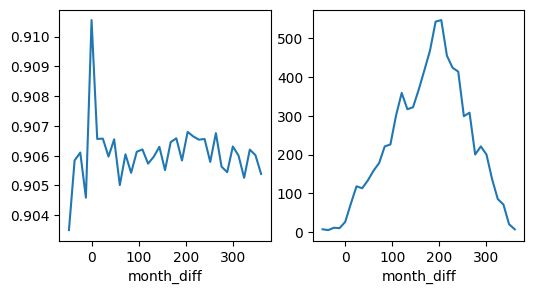

In [36]:
f,a = plt.subplots(1,2,figsize=(6,3))

dfs.groupby(dfs.month_diff//12*12).similarity.mean().plot(ax=a[0])
dfs.groupby(dfs.month_diff//12*12).size().plot(ax=a[1])

In [225]:
for i,r in dfs.nlargest(15,'similarity').iterrows():
    print(r['month_diff'], "month difference:")
    print("Similarity: ", round(r['similarity'],3))
    print(f"\tREPORT: {r['report_sent']}")
    print(f"\tKST: {r['kst_sent']}")

49 month difference:
Similarity:  0.987
	REPORT: Naast de verwerving van de jachtvliegtuigen zelf omvat het project de verwerving van bijbehorende simulatoren, initiële reservedelen, infrastructuur, speciale gereedschappen, meet- en testapparatuur, documentatie, initiële opleidingen en transport, alsmede de betaling van btw.
	KST: Naast de verwerving van jachtvliegtuigen omvat het project ook de verwerving van bijbehorende simulatoren, reservedelen, infra- structuur, speciale gereedschappen, meet- en testapparatuur, documen- tatie, opleidingen, transport en btw.
36 month difference:
Similarity:  0.987
	REPORT: Naast de verwerving van jacht- vliegtuigen omvat het project de verwerving van bijbehorende simulatoren, initiële reservedelen, infrastructuur, speciale gereed- schappen, meet- en testapparatuur, documentatie, initiële oplei- dingen en transport, alsmede de betaling van btw.
	KST: Naast de verwerving van jachtvliegtuigen omvat het project ook de verwerving van bijbehorende simula

In [82]:
results[results.similarity>.95]

,report_sent,report_date,kst_sent,kst_date,similarity,tempdist,tempdist_m,month_diff
1779,Hierdoor is het achteraf niet mogelijk na te g...,1995-12-12,Zo kan achteraf niet worden vastgesteld of het...,2020-07-15,0.971300,-8982 days,-2.557237e+16,295
1859,Hierdoor is het achteraf niet mogelijk na te g...,1995-12-12,Zo kan achteraf niet worden vastgesteld of het...,2020-07-15,0.971300,-8982 days,-2.557237e+16,295
3576,De Rekenkamer concludeert dat ook op uitvoerin...,1996-08-29,"Er moet nog een hoop verbeteren, zo stelt ook ...",2013-08-12,0.962627,-6192 days,-1.762905e+16,204
11433,De Rekenkamer deed op grond van haar onderzoek...,1998-10-29,Op basis van haar onderzoek doet de Rekenkamer...,2017-07-14,0.956696,-6833 days,-1.945402e+16,225
15711,De Rekenkamer doet op grond van haar onderzoek...,1999-09-09,Op basis van haar onderzoek doet de Rekenkamer...,2017-07-14,0.962784,-6518 days,-1.855720e+16,214
...,...,...,...,...,...,...,...,...
98649,Deze uitzondering houdt in dat Nederlandse vee...,2019-06-20,Door deze uitzondering kunnen Nederlandse boer...,2020-01-22,0.956676,-216 days,-6.149669e+14,7
99044,Ook zouden de beleidsdoorlichtingen meer inzic...,2019-09-12,De beleidsdoorlichtingen moeten beter inzicht ...,2015-08-11,0.964677,1493 days,4.250674e+15,-49
99432,Na de totstandkoming van Autobrief II is in he...,2019-11-27,In het regeerakkoord is het streven opgenomen ...,2019-03-06,0.963015,266 days,7.573203e+14,-8
101028,Het Zorginstituut zelf is terughoudend met de ...,2020-10-13,Het Zorginstituut zelf is terughoudend gebleke...,2020-12-03,0.964241,-51 days,-1.452005e+14,2


In [ ]:
results.loc[15711]['report_sent']

'Hierdoor is het achteraf niet mogelijk na te gaan in welke mate het beoogde doel is bereikt.'